In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Rescaling,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import load_img, img_to_array

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
data_dir = Path(
    r"C:\Users\asus\.keras\datasets\flower_photos\flower_photos"
)

print("Dataset path:")
print(data_dir)

Dataset path:
C:\Users\asus\.keras\datasets\flower_photos\flower_photos


In [4]:
folders = [x.name for x in data_dir.iterdir() if x.is_dir()]

print("Flower folders:")
print(folders)

Flower folders:
['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [5]:
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print("Classes:", class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
num_classes = len(class_names)

model = Sequential([
    Input(shape=(180, 180, 3)),

    Rescaling(1./255),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 178, 178, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 89, 89, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 87, 87, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 43, 43, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 41, 41, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 20, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 51200)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       6,553,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,647,621 (25.36 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
Input(shape=(180, 180, 3))

<KerasTensor shape=(None, 180, 180, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_12>

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15


C:\Users\asus\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.4016 - loss: 1.3835 - val_accuracy: 0.5082 - val_loss: 1.1729
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 900ms/step - accuracy: 0.5300 - loss: 1.1407 - val_accuracy: 0.6049 - val_loss: 1.0004
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 86s 941ms/step - accuracy: 0.6100 - loss: 1.0031 - val_accuracy: 0.6213 - val_loss: 0.9139
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 904ms/step - accuracy: 0.6672 - loss: 0.8520 - val_accuracy: 0.6281 - val_loss: 0.9051
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 894ms/step - accuracy: 0.7173 - loss: 0.7332 - val_accuracy: 0.6866 - val_loss: 0.8009
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 889ms/step - accuracy: 0.7950 - loss: 0.5644 - val_accuracy: 0.6662 - val_loss: 0.8298
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 83s 906ms/step - accuracy: 0.8420 - loss: 0.4482 - val_accuracy: 0.6866 - val_loss: 0.8283
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 88s 955ms/step - accuracy: 0.8702 - loss: 0.3694 - val_accuracy: 0.6880 

In [10]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", round(accuracy * 100, 2), "%")

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 239ms/step - accuracy: 0.6880 - loss: 1.3598
Validation Loss: 1.3598146438598633
Validation Accuracy: 68.8 %


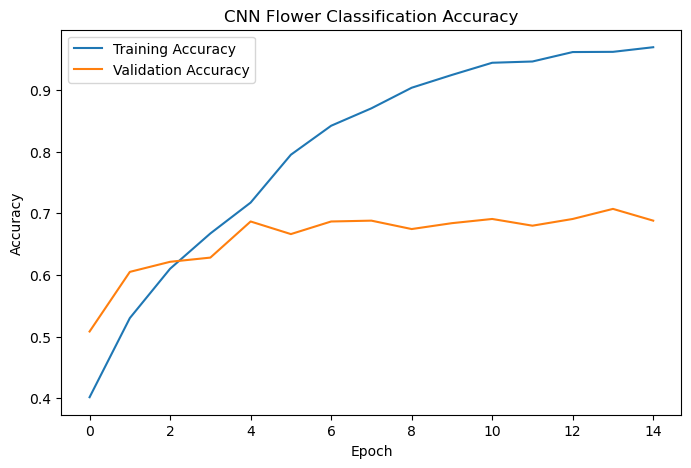

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Flower Classification Accuracy")
plt.legend()
plt.show()

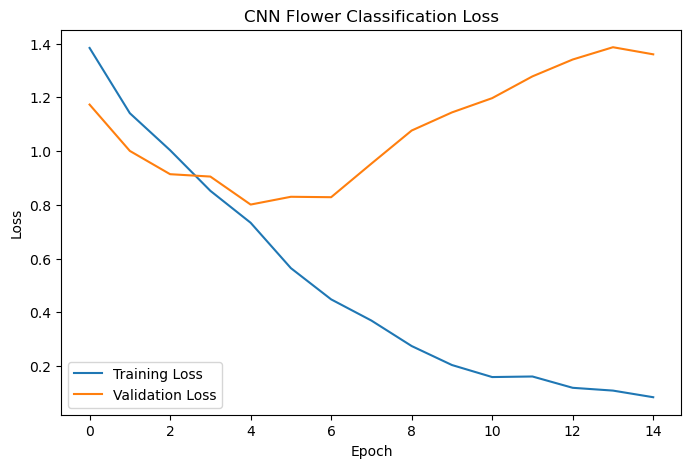

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Flower Classification Loss")
plt.legend()
plt.show()

In [13]:
model.save("flower_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [14]:
image_path = r"C:\Users\asus\Downloads\Elegant White Rose in Soft Greenery.png"

img = load_img(
    image_path,
    target_size=(180, 180)
)

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
predicted_class = class_names[predicted_index]
confidence = np.max(prediction) * 100

print("Predicted Flower:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
Predicted Flower: roses
Confidence: 99.87 %
